** Objetivo - ** Prever a ocorrência de hipertiroidismo com base em variáveis clínicas, auxiliando diagnosticos precoces.


In [48]:
import pandas as pd
df = pd.read_csv('Base_M43_pratique_Hypothyroid.csv')

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3772 entries, 0 to 3771
Data columns (total 30 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   age                        3772 non-null   object
 1   sex                        3772 non-null   object
 2   on thyroxine               3772 non-null   object
 3   query on thyroxine         3772 non-null   object
 4   on antithyroid medication  3772 non-null   object
 5   sick                       3772 non-null   object
 6   pregnant                   3772 non-null   object
 7   thyroid surgery            3772 non-null   object
 8   I131 treatment             3772 non-null   object
 9   query hypothyroid          3772 non-null   object
 10  query hyperthyroid         3772 non-null   object
 11  lithium                    3772 non-null   object
 12  goitre                     3772 non-null   object
 13  tumor                      3772 non-null   object
 14  hypopitu

**2 Carregar e Tratar a base**

In [49]:
df.head(5)

,age,sex,on thyroxine,query on thyroxine,on antithyroid medication,sick,pregnant,thyroid surgery,I131 treatment,query hypothyroid,...,TT4 measured,TT4,T4U measured,T4U,FTI measured,FTI,TBG measured,TBG,referral source,binaryClass
0,41,F,f,f,f,f,f,f,f,f,...,t,125,t,1.14,t,109,f,?,SVHC,P
1,23,F,f,f,f,f,f,f,f,f,...,t,102,f,?,f,?,f,?,other,P
2,46,M,f,f,f,f,f,f,f,f,...,t,109,t,0.91,t,120,f,?,other,P
3,70,F,t,f,f,f,f,f,f,f,...,t,175,f,?,f,?,f,?,other,P
4,70,F,f,f,f,f,f,f,f,f,...,t,61,t,0.87,t,70,f,?,SVI,P


Vou padronizar nossa base, para poder dar continuidade ao projeto.

In [50]:
# Percorre todas as colunas do DataFrame que são do tipo "object" (texto)
for col in df.select_dtypes(include='object').columns:
    
    # Para cada coluna, aplica uma função em cada valor da coluna
    df[col] = df[col].apply(
        
        # lambda = função anônima (função rápida sem nome)
        lambda x: 
        
        # Verifica se o valor é uma string (texto)
        x.strip().lower() if isinstance(x, str)# Remove espaços em branco e converte para minúsculas se for string
        
        # Se NÃO for string (ex: NaN), mantém o valor original
        else x
    )



com essa função assima, padronizo todas as colunas categoricas, removendo espaços e convertendo pra minuscula

In [51]:
#Visualizar os valores únicos de cada coluna
for col in df.columns:
    print(f'{col}: {df[col].unique()}') 

age: ['41' '23' '46' '70' '18' '59' '80' '66' '68' '84' '67' '71' '28' '65'
 '42' '63' '51' '81' '54' '55' '60' '25' '73' '34' '78' '37' '85' '26'
 '58' '64' '44' '48' '61' '35' '83' '21' '87' '53' '77' '27' '69' '74'
 '38' '76' '45' '36' '22' '43' '72' '82' '31' '39' '49' '62' '57' '1' '50'
 '30' '29' '75' '19' '7' '79' '17' '24' '15' '32' '47' '16' '52' '33' '13'
 '10' '89' '56' '20' '90' '40' '88' '14' '86' '94' '12' '4' '11' '8' '5'
 '455' '2' '91' '6' '?' '93' '92']
sex: ['f' 'm' '?']
on thyroxine: ['f' 't']
query on thyroxine: ['f' 't']
on antithyroid medication: ['f' 't']
sick: ['f' 't']
pregnant: ['f' 't']
thyroid surgery: ['f' 't']
I131 treatment: ['f' 't']
query hypothyroid: ['f' 't']
query hyperthyroid: ['f' 't']
lithium: ['f' 't']
goitre: ['f' 't']
tumor: ['f' 't']
hypopituitary: ['f' 't']
psych: ['f' 't']
TSH measured: ['t' 'f']
TSH: ['1.3' '4.1' '0.98' '0.16' '0.72' '0.03' '?' '2.2' '0.6' '2.4' '1.1' '2.8'
 '3.3' '12' '1.2' '1.5' '6' '2.1' '0.1' '0.8' '1.9' '3.1' '0.2' '1

Aqui identifico que base precisa ser tratada pois, possui valores irreiais na coluna idade e outras colunas possuem o valor "?" 

In [52]:
import numpy as np
df['age'] = pd.to_numeric(df['age'], errors='coerce')#A função pd.to_numeric com errors='coerce' irá converter os valores que não podem ser convertidos para NaN, ou seja, os valores "?" serão convertidos para NaN. Depois disso, podemos remover as linhas com NaN na coluna "age" antes de plotar o boxplot.
df = df.dropna(subset=['age'])

df['TSH'] = pd.to_numeric(df['TSH'], errors='coerce')
df = df.dropna(subset=['TSH'])

df['T3'] = pd.to_numeric(df['T3'], errors='coerce') 
df = df.dropna(subset=['T3'])

df['TT4'] = pd.to_numeric(df['TT4'], errors='coerce') 
df = df.dropna(subset=['TT4'])  

df['T4U'] = pd.to_numeric(df['T4U'], errors='coerce') 
df = df.dropna(subset=['T4U'])

df['FTI'] = pd.to_numeric(df['FTI'], errors='coerce') 
df = df.dropna(subset=['FTI'])  

#Todos os valores não numéricos foram substituídos por NaN.

df.info()



<class 'pandas.core.frame.DataFrame'>
Index: 2751 entries, 0 to 3771
Data columns (total 30 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   age                        2751 non-null   float64
 1   sex                        2751 non-null   object 
 2   on thyroxine               2751 non-null   object 
 3   query on thyroxine         2751 non-null   object 
 4   on antithyroid medication  2751 non-null   object 
 5   sick                       2751 non-null   object 
 6   pregnant                   2751 non-null   object 
 7   thyroid surgery            2751 non-null   object 
 8   I131 treatment             2751 non-null   object 
 9   query hypothyroid          2751 non-null   object 
 10  query hyperthyroid         2751 non-null   object 
 11  lithium                    2751 non-null   object 
 12  goitre                     2751 non-null   object 
 13  tumor                      2751 non-null   object 
 1

In [53]:
df['sex'].value_counts()

sex
f    1764
m     879
?     108
Name: count, dtype: int64

Pra preservar o maximo de dados, vou verificar quantos dos sexo "?" podem estar grávida para que eu possa classicar como "F" 

In [54]:
df_filtrado = df[df['sex'] == '?']
df_filtrado['pregnant'].value_counts()

pregnant
f    106
t      2
Name: count, dtype: int64

A intenção foi boa, mas aqui temos apenas 2 linhas que podemos converter pra 'f'

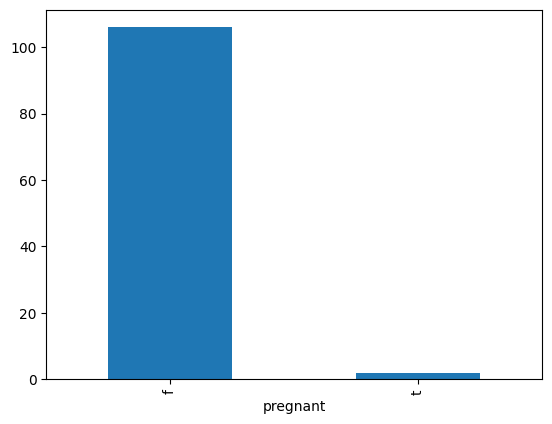

In [55]:
import matplotlib.pyplot as plt

df_filtrado['pregnant'].value_counts().plot(kind='bar')#Grafico rápido, só pra confirmar valores vistos antes.
plt.show()

In [56]:
# Se pregnant == 't' e sex desconhecido ("?"), assumir feminino ('f')
# Corrigir inconsistência
df.loc[(df['sex'] == '?') & (df['pregnant'] == 't'), 'sex'] = 'f'

# Depois tratar restantes
df['sex'] = df['sex'].map({'f': 0, 'm': 1, '?': np.nan})

df['sex'].value_counts()#Verificando se foi feito as alterações.





sex
0.0    1766
1.0     879
Name: count, dtype: int64

In [57]:
df.dropna(subset=['sex'], inplace=True)#Removendo as linhas com valores NaN na coluna
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2645 entries, 0 to 3771
Data columns (total 30 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   age                        2645 non-null   float64
 1   sex                        2645 non-null   float64
 2   on thyroxine               2645 non-null   object 
 3   query on thyroxine         2645 non-null   object 
 4   on antithyroid medication  2645 non-null   object 
 5   sick                       2645 non-null   object 
 6   pregnant                   2645 non-null   object 
 7   thyroid surgery            2645 non-null   object 
 8   I131 treatment             2645 non-null   object 
 9   query hypothyroid          2645 non-null   object 
 10  query hyperthyroid         2645 non-null   object 
 11  lithium                    2645 non-null   object 
 12  goitre                     2645 non-null   object 
 13  tumor                      2645 non-null   object 
 1

In [58]:
df['sex'] = df['sex'].astype(int)
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2645 entries, 0 to 3771
Data columns (total 30 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   age                        2645 non-null   float64
 1   sex                        2645 non-null   int64  
 2   on thyroxine               2645 non-null   object 
 3   query on thyroxine         2645 non-null   object 
 4   on antithyroid medication  2645 non-null   object 
 5   sick                       2645 non-null   object 
 6   pregnant                   2645 non-null   object 
 7   thyroid surgery            2645 non-null   object 
 8   I131 treatment             2645 non-null   object 
 9   query hypothyroid          2645 non-null   object 
 10  query hyperthyroid         2645 non-null   object 
 11  lithium                    2645 non-null   object 
 12  goitre                     2645 non-null   object 
 13  tumor                      2645 non-null   object 
 1

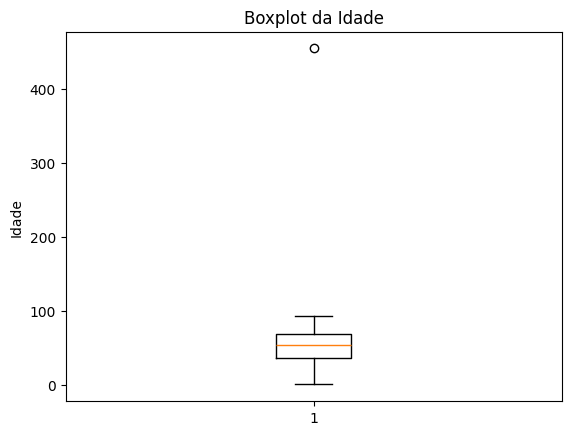

In [59]:
import matplotlib.pyplot as plt

plt.boxplot(df['age'])
plt.title('Boxplot da Idade')   
plt.ylabel('Idade')
plt.show()



Fiz uma pesquisa rápida, sobre  a faixa etária de idade e vamos limitar nossa base de acordo. de 0 a 100 
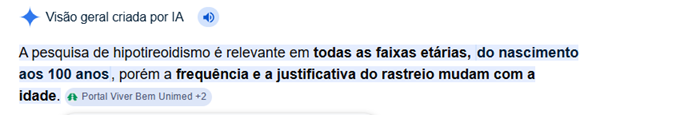
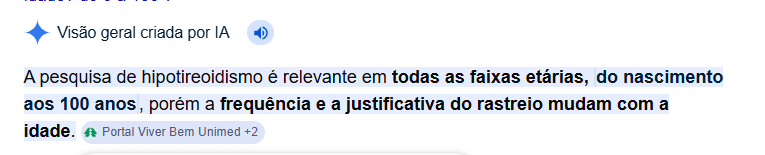

In [60]:
df = df[df['age'] <= 100] #Removendo valores de idade maiores que 100, pois são considerados outliers e podem distorcer a análise.
df['age'].max()#Verificando o valor máximo da idade após a remoção dos outliers.

np.float64(94.0)

Agora vamos tratar as colunas booleanas que estão categoricas.


In [61]:
for col in df.columns:
    valores_unicos = set(df[col].unique())#Criando um conjunto (set) dos valores únicos da coluna para facilitar a verificação.
    
    if valores_unicos.issubset({'t', 'f'}):#
        df[col] = df[col].map({'t': 1, 'f': 0})

df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2644 entries, 0 to 3771
Data columns (total 30 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   age                        2644 non-null   float64
 1   sex                        2644 non-null   int64  
 2   on thyroxine               2644 non-null   int64  
 3   query on thyroxine         2644 non-null   int64  
 4   on antithyroid medication  2644 non-null   int64  
 5   sick                       2644 non-null   int64  
 6   pregnant                   2644 non-null   int64  
 7   thyroid surgery            2644 non-null   int64  
 8   I131 treatment             2644 non-null   int64  
 9   query hypothyroid          2644 non-null   int64  
 10  query hyperthyroid         2644 non-null   int64  
 11  lithium                    2644 non-null   int64  
 12  goitre                     2644 non-null   int64  
 13  tumor                      2644 non-null   int64  
 1

In [62]:
df['TBG'].value_counts()

TBG
?    2644
Name: count, dtype: int64

In [63]:
#Exclui essa coluna pois não possui dados, e pra evitar eventuais problemas na hora de treinar o modelo.
df.drop(columns=['TBG'], inplace=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2644 entries, 0 to 3771
Data columns (total 29 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   age                        2644 non-null   float64
 1   sex                        2644 non-null   int64  
 2   on thyroxine               2644 non-null   int64  
 3   query on thyroxine         2644 non-null   int64  
 4   on antithyroid medication  2644 non-null   int64  
 5   sick                       2644 non-null   int64  
 6   pregnant                   2644 non-null   int64  
 7   thyroid surgery            2644 non-null   int64  
 8   I131 treatment             2644 non-null   int64  
 9   query hypothyroid          2644 non-null   int64  
 10  query hyperthyroid         2644 non-null   int64  
 11  lithium                    2644 non-null   int64  
 12  goitre                     2644 non-null   int64  
 13  tumor                      2644 non-null   int64  
 1

In [64]:
df['referral source'].str.upper().value_counts()#Deixei maiusculo pra que todos dessa categoria fiquem iguais aos outros.

referral source
OTHER    1238
SVI       928
SVHC      359
STMW       85
SVHD       34
Name: count, dtype: int64

In [65]:
df_original = df.copy() #Dei uma cópia do DataFrame original antes de fazer o one hot encoding, para caso seja necessário voltar atrás ou comparar os dados antes e depois da transformação.
df = pd.get_dummies(df, columns=['referral source'])#Fazendo o one hot enconding da coluna "referral source", criando colunas binárias para cada categoria presente nessa coluna.
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2644 entries, 0 to 3771
Data columns (total 33 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   age                        2644 non-null   float64
 1   sex                        2644 non-null   int64  
 2   on thyroxine               2644 non-null   int64  
 3   query on thyroxine         2644 non-null   int64  
 4   on antithyroid medication  2644 non-null   int64  
 5   sick                       2644 non-null   int64  
 6   pregnant                   2644 non-null   int64  
 7   thyroid surgery            2644 non-null   int64  
 8   I131 treatment             2644 non-null   int64  
 9   query hypothyroid          2644 non-null   int64  
 10  query hyperthyroid         2644 non-null   int64  
 11  lithium                    2644 non-null   int64  
 12  goitre                     2644 non-null   int64  
 13  tumor                      2644 non-null   int64  
 1

In [66]:
df['binaryClass'].value_counts()

binaryClass
p    2428
n     216
Name: count, dtype: int64

In [67]:
df['binaryClass'] = df['binaryClass'].map({'n': 0, 'p': 1})#Convertendo a coluna "binaryClass" para valores numéricos, onde 'negative' é mapeado para 0 e 'positive' é mapeado para 1.





**Plotar Graficos de correlação e tirar insights**

**Pronto, Base Tratada! agora vou analisar e tirar alguns insights, plotando alguns gráficos e analisando correlações que me ajudem a compreender melhor a base de dados.

In [68]:
import plotly.express as px

corr = df.corr()

fig = px.imshow(
    corr,
    color_continuous_scale='RdBu_r',
    aspect='auto'
)

fig.update_layout(
    title='Mapa de Correlação',
    width=900,
    height=700
)

fig.show()

Plotei um grafico de correlação geral, pra dar uma olhada de forma ampla, mais a frente vou detalhando mais e mais pra extrair o maximo de informação da nossa base.

In [69]:

corr_target = df.corr()['binaryClass'].sort_values(ascending=False) #Calcula a correlação de todas as colunas com a coluna "binaryClass" e ordena os resultados em ordem decrescente.
corr_target = corr_target[abs(corr_target) > 0.2]

fig = px.bar(
    x=corr_target.values,
    y=corr_target.index,
    orientation='h',
    title='Correlação com Target'
)

fig.show()

Bom aqui fica mais fácil notar as principais variaveis que influenciam nosso alvo, TSH com correlação negativa, e os outros TT4, FTI

Agora vou agrupar e cruzar alguns dados, pra entender melhor nossa base, antes de simplesmente modelar: Analisar proporções em Sexo, idade, Referal Sources

In [70]:
df['sex_label'] = df['sex'].map({0:"Mulher", 1:"Homem"})#Criando uma nova coluna

sex_alvo =(
    df
    .groupby('binaryClass')['sex_label']#Agrupou os valores da coluna total de sexo por classe (binaryClass).
    .value_counts(normalize=True)#Proporcionalizou os valores agrupados.
    .rename('Proporção')
    .reset_index()
)

fig = px.bar(
    sex_alvo,
    x='binaryClass',
    y='Proporção',
    color='sex_label',
    title='Proporção de Sexo por Classe',
    barmode='group'
)

fig.show()

Aqui observo que em nosso alvo positivo, os homens crescem um pouco na proporção, isso sem levar em conta que a nossa base esta desbalanceada, contendo mais registro de mulher do que os homens.

In [71]:
referral = (
    df_original.groupby('binaryClass')['referral source'].value_counts(normalize=True).rename('Proporção').reset_index()
)

fig = px.bar(
    referral,
    x='binaryClass',
    y='Proporção',
    color='referral source',
    title='Proporção de Referral Source por Classe',
    barmode='group'
)

fig.show()

Aqui observo que as principais fonte de referência são SVI, SVHC e OTHER.

In [72]:
idade_alvo =(
    df.groupby('binaryClass')['age']
    .value_counts(normalize=True)
    .rename('Proporção')
    .reset_index()
)

fig = px.bar(
    idade_alvo,
    x='age',
    y='Proporção',
    color='binaryClass',
    title='Proporção de Idade por Classe',
    barmode='group'
)

fig.show()

Aqui confirmo o que foi visto antes no grafico de correlação(geral), que idade não tem uma correlação direta com o nosso alvo, pois estão bem destribuidos e há tanto positivo quanto negativos em diversas idades.

**3 preparar modelos e avaliar**

In [73]:
from sklearn.model_selection import train_test_split, cross_validate, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier 
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

df_code = df.drop(columns=['sex_label'])#Criando uma nova variável "df_code" que é uma cópia do DataFrame "df" remvendo um coluna rótulo

x = df_code.drop(columns=['binaryClass'])#Definindo as variáveis independentes (X) removendo a coluna "binaryClass" do DataFrame.
y = df_code['binaryClass']#Definindo a variável dependente (y) target.


y.value_counts()

binaryClass
1    2428
0     216
Name: count, dtype: int64

In [74]:
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

pipeline_rf = Pipeline([
    ('smote', SMOTE(random_state=1)),
    ('model', RandomForestClassifier(
        random_state=1,
        n_estimators=200,#
        max_depth=10,#max
        n_jobs=-1#
        ))
])



In [75]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=1)
scoring_rf = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
scores = cross_validate(pipeline_rf, x, y, cv=cv, scoring=scoring_rf)#Realizando a validação cruzada usando o pipeline que inclui o SMOTE para balanceamento de classes e o RandomForestClassifier como modelo.
resultado_rf = pd.DataFrame(scores)

for metric in scoring_rf:
    print(f'{metric}: {scores[f"test_{metric}"].mean():.4f}')

accuracy: 0.9939
precision: 0.9979
recall: 0.9955
f1: 0.9967
roc_auc: 0.9993


Métricas excelentes do nosso modelo mas, antes de aperfeiçoar esse pipeline vou testar outros, e o que melhor que se sobressair vou aperfeiçoar.

In [76]:
from sklearn.linear_model import LogisticRegression

pipeline_lr = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('model', LogisticRegression(max_iter=1000))
])

In [77]:
scoring_lr = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
scores = cross_validate(pipeline_lr, x, y, cv=cv, scoring=scoring_lr)
resultado_lr = pd.DataFrame(scores)

for metric in scoring_lr:
    print(f'{metric}: {scores[f"test_{metric}"].mean():.4f}')

d:\Helton\Programacao_EBAC\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning:

lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression

d:\Helton\Programacao_EBAC\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning:

lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the doc

accuracy: 0.9792
precision: 0.9909
recall: 0.9864
f1: 0.9887
roc_auc: 0.9905


In [78]:
dif_modelo = resultado_rf.mean() - resultado_lr.mean()
print(dif_modelo)

fit_time          0.056908
score_time        0.107152
test_accuracy     0.014749
test_precision    0.006998
test_recall       0.009062
test_f1           0.008047
test_roc_auc      0.008722
dtype: float64


Aqui confirmo que o modelo Random Forest é superior em todas as metricas analisadas, agora vou comparar com Xboost


In [79]:
import xgboost as xgb
from xgboost import XGBClassifier

pipeline_xboost = Pipeline([
    ('smote', SMOTE(random_state=1)),
    ('model', XGBClassifier(
        random_state=1,
        n_estimators=200,
        max_depth=10,
        n_jobs=-1
    ))
])

In [80]:
scoring_xgb = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
scores = cross_validate(pipeline_xboost, x, y, cv=cv, scoring=scoring_xgb)
resultado_xgb = pd.DataFrame(scores)

for metric in scoring_xgb:
    print(f'{metric}: {scores[f"test_{metric}"].mean():.4f}')

accuracy: 0.9947
precision: 0.9988
recall: 0.9955
f1: 0.9971
roc_auc: 0.9980


In [81]:
avaliacao = pd.DataFrame({
    'xgboost': resultado_xgb.mean(),
    'random_forest': resultado_rf.mean(),
    'logistic_regression': resultado_lr.mean()
}).T #

print(avaliacao)

                     fit_time  score_time  test_accuracy  test_precision  \
xgboost              0.132120    0.025027       0.994706        0.998763   
random_forest        0.417289    0.117173       0.993947        0.997936   
logistic_regression  0.360381    0.010021       0.979198        0.990938   

                     test_recall   test_f1  test_roc_auc  
xgboost                 0.995470  0.997113      0.998003  
random_forest           0.995469  0.996699      0.999255  
logistic_regression     0.986407  0.988653      0.990533  


Aqui o Xboost praticamente manteve métricas semelhante e com algumas inferior ao modelo Random Forest, sendo assim vou dar continuidade com o Random Forest, desevolver o modelo, treinar, testar, plotar alguns gráficos que para ter a compreensão do nosso modelo.

In [82]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=1, stratify=y)#stra

pipeline_rf.fit(x_train, y_train)#Treinando o modelo com as bases

,steps,"[('smote', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,sampling_strategy,'auto'
,random_state,1
,k_neighbors,5
,n_estimators,200
,criterion,'gini'
,max_depth,10
,min_samples_split,2


<Axes: >

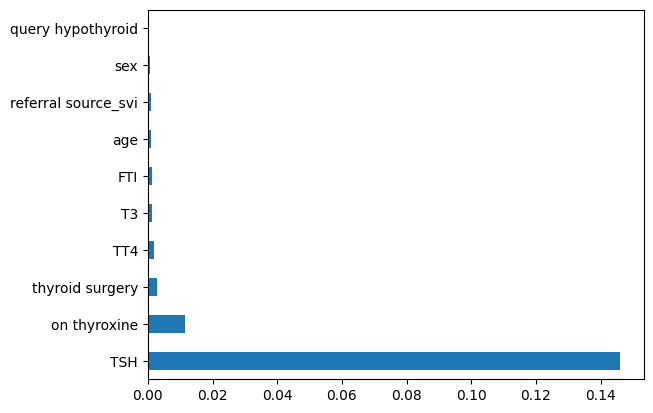

In [83]:
from sklearn.inspection import permutation_importance

#A função permutation_importance é usada para calcular a importância das características (features) em um modelo de machine learning. Ela faz isso permutando os valores de cada característica e avaliando o impacto na performance do modelo. Quanto maior a queda na performance, mais importante é a característica.
result = permutation_importance(
    pipeline_rf,
    x_train,
    y_train,
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

perm_imp = pd.Series(result.importances_mean, index=x.columns).sort_values(ascending=False)

perm_imp.head(10).plot(kind='barh')

Aqui vejo que as principais features do modelo é o TSH, que no inicio vimos uma forte correlação negativa com o nosso alvo, sendo asssim, quanto maior o nosso TSH, menor são as chances de hipertiroidismo ser positivo. Porém observo também que a variável "on thyroxine" não estava correlacionada direta com nosso target, mas tem uma importância significativa na classificação do nosso modelo.

In [84]:
thyroxine = df_code.corr()['on thyroxine'].sort_values(ascending=False)#Calcula a correlação de todas as colunas com a coluna "on thyroxine" e ordena os resultados em ordem decrescente.
thyroxine = thyroxine[abs(thyroxine) > 0.1]#Filtra as correlações, mantendo apenas aquelas cujo valor absoluto seja maior que 0.1, ou seja, aquelas que têm uma correlação mais forte com a coluna "on thyroxine".

fig = px.bar(
    x=thyroxine.values,
    y=thyroxine.index,
    orientation='h',#Cria um gráfico de barras horizontais, onde os valores de correlação são representados no eixo x e os nomes das colunas no eixo y.
    title='Correlação com on thyroxine'
)

fig.show()

Aqui consigo perceber do porque nossa varável "on thyroxine" é importante mesmo sem ter correlação direta com o nosso alvo, pois ela possui correlação relevante nas princiapais variavies que influenciam nosso alvo. 

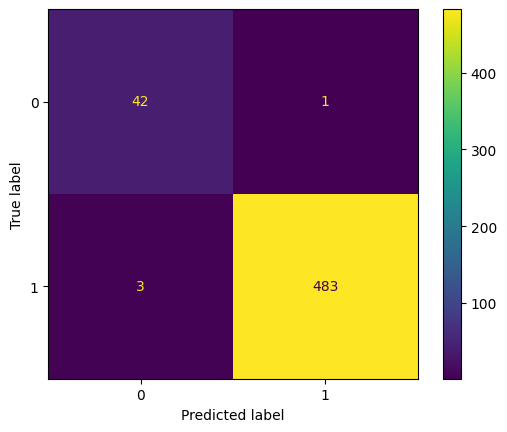

In [85]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(pipeline_rf, x_test, y_test)


Analisando essa matriz posso dizer que: o modelo na classificação positiva, acertou 483 vezes e deixou de classificar 3 positivos, resultando numa taxa de acerto aproximada de 99,4%, e na classificação negativa, acertou 42 vezes e classificou 1 falso positivo a Hiper Tiroidismo, resultando numa taxa de acerto aproximada de 97,6%

**Aplicando Hiperparâmetros pra melhorar nosso modelo**

In [86]:
param_rf = {
    'model__n_estimators': [100, 200],
    'model__max_depth': [None, 10, 20],
    'model__min_samples_split': [2, 5],
}

In [87]:
from sklearn.model_selection import GridSearchCV

#GridSearchCV é uma técnica de busca exaustiva para encontrar os melhores hiperparâmetros de um modelo de machine learning. Ele testa todas as combinações possíveis dos hiperparâmetros especificados e avalia o desempenho do modelo usando validação cruzada. O resultado é o conjunto de hiperparâmetros que proporciona a melhor performance do modelo com base na métrica escolhida (neste caso, recall).
grid_rf = GridSearchCV(
    pipeline_rf,
    param_rf,
    cv=cv,
    scoring='recall', #Procurar o melhor modelo com base na métrica de recall, que é importante para problemas de classificação onde o objetivo é minimizar os falsos negativos.
    n_jobs=-1
)

grid_rf.fit(x_train, y_train)

,estimator,Pipeline(step...om_state=1))])
,param_grid,"{'model__max_depth': [None, 10, ...], 'model__min_samples_split': [2, 5], 'model__n_estimators': [100, 200]}"
,scoring,'recall'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,sampling_strategy,'auto'


In [88]:

best_model = grid_rf.best_estimator_  

y_pred = best_model.predict(x_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.95      0.98      0.97        43
           1       1.00      1.00      1.00       486

    accuracy                           0.99       529
   macro avg       0.98      0.99      0.98       529
weighted avg       0.99      0.99      0.99       529



Perfeito, consegui aprimorar o recall, priorizando não deixar passar falsos negativos, em outras palavras o modelo vai classificar mais os positivios mesmo que alguns sejam falsos positivos mas, como nossas taxa de precisão também esta alta, haverá poucos falsos positivos. sendo um excelente modelo.

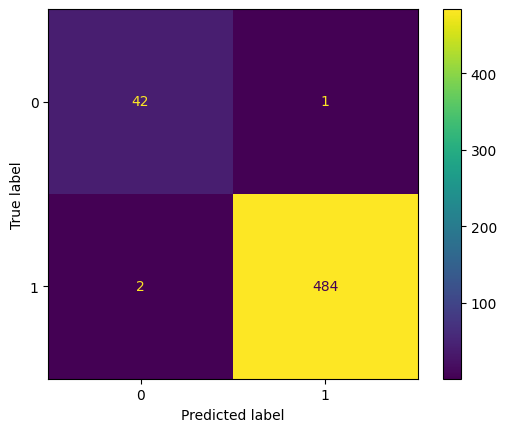

In [89]:
ConfusionMatrixDisplay.from_estimator(best_model, x_test, y_test)

Pelo gráfico confirmamos que ele classificou mais verdadeiros positivos do que antes. que era o obejtivo dos hiperparâmetros

<Axes: >

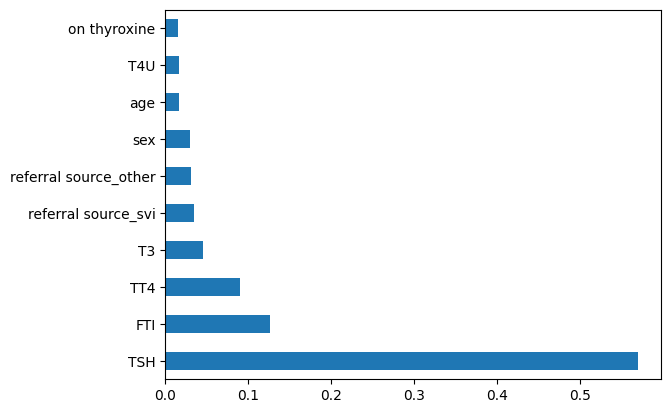

In [90]:
import pandas as pd

model = best_model.named_steps['model']

feat_imp = pd.Series(
    model.feature_importances_, #obter as feature importances do modelo Random Forest
    index=x.columns #obter os nomes das colunas do DataFrame x
).sort_values(ascending=False)

feat_imp.head(10).plot(kind='barh')

Aqui vejo que as principais features mudaram um pouco de acordo, mediante a aplicação dos hiperparâmetros mas, o TSH Continua sendo nosso divisor de águas, a variavel mais importante da nossa base.


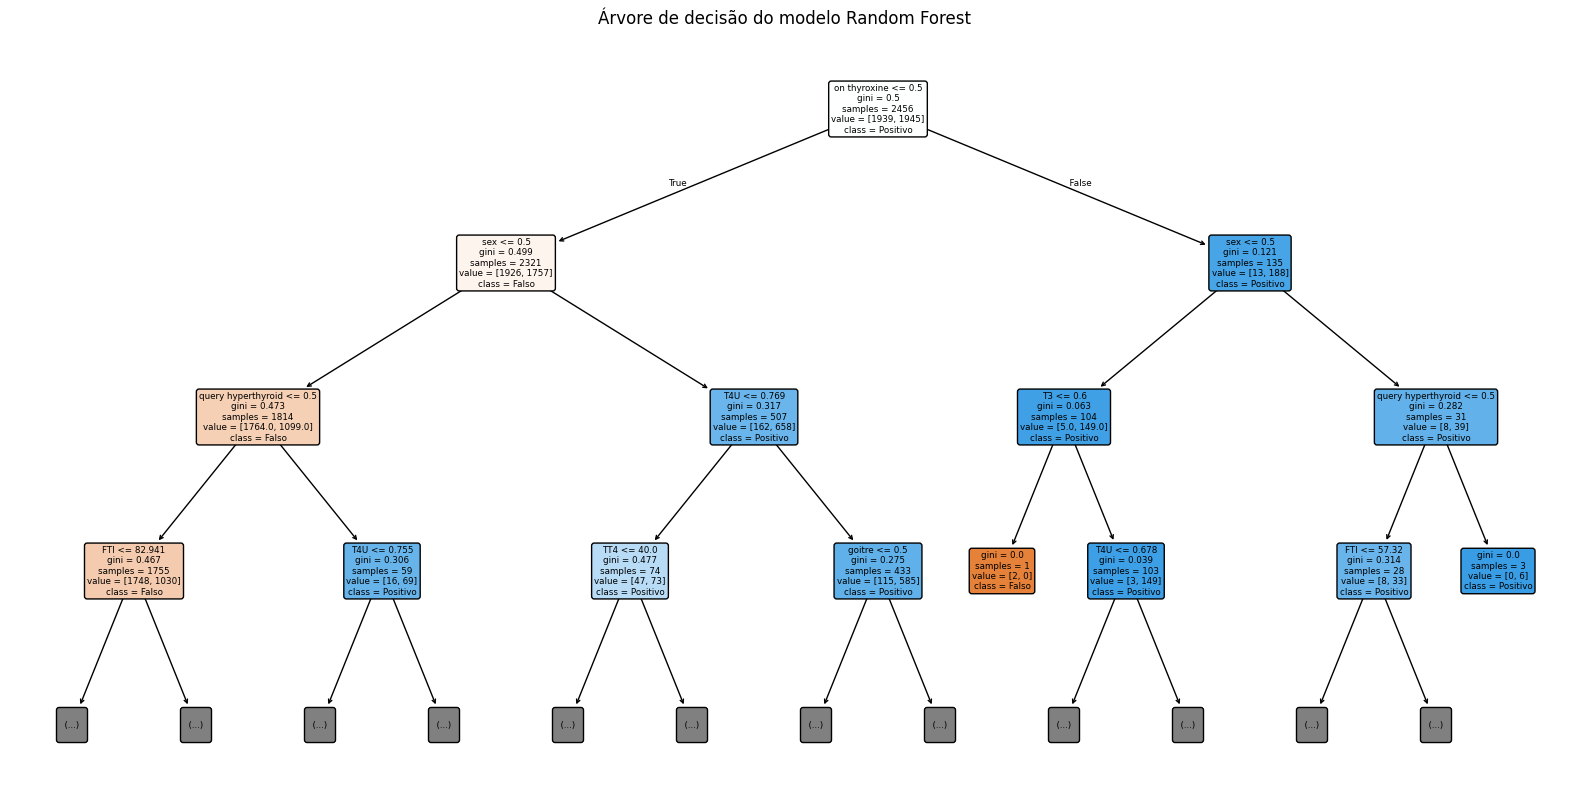

In [91]:

from sklearn.tree import plot_tree


# 2. Escolha uma das árvores (ex: a primeira, de índice 0)
uma_arvore = model.estimators_[0]

# 3. Plotar
plt.figure(figsize=(20, 10))
plot_tree(uma_arvore, 
          feature_names=x.columns,       # Nomes das colunas de entrada
          class_names=['Falso', 'Positivo'], 
          filled=True, 
          max_depth=3,                   # Limita para ficar legível
          rounded=True)
plt.title("Árvore de decisão do modelo Random Forest")
plt.show()


Pelo gráfico da árvore do nosso modelo, podemos entender que ele considera o uso de tiroxina, os níveis de TSH e o sexo como os três filtros iniciais mais poderosos para separar quem tem ou não o problema.

**Conclusão**

👉 Modelo escolhido: Random Forest (detro os modelos testados, foi o melhor)

👉 Motivo: Maior recall 

👉 Principais variáveis:

    on_thiroxine,
    age,
    TSH

👉 Insight:

    variável (TSH) quando menor, ela aumenta a chance de classificar como positivo
    e a variavél (on_thiroxine) é exencial pro modelo classificar melhor, tornando umas das principais variaveis.  